# Step 1 — Real NGAFID-MC baseline (no LLM)

Step 0 proved the loop on synthetic data. Step 1 runs the **same tools on the real
Kaggle data** and records the honest baseline AUC. No LLM yet.

## What the real data actually is
The download is **not** one CSV per flight. It is **one big CSV per maintenance
cluster** — C28 ≈ 4 GB, C37 ≈ 1.5 GB — with every flight's per-second rows stacked
and delimited by an `id` column:

```
<22 sensors>, id, plane_id, split, date_diff, before_after
```

- `id` → flight (rows are contiguous per flight)
- `plane_id` → tail number → **GroupKFold group** (leakage-free validation)
- `before_after` → the label: **`before` = pre-maintenance = problematic = 1**, `after` = good = 0
- `split` → the paper's own train/test partition (optional to honour)
- `date_diff` → days from maintenance

**The paper's filters are already applied.** The per-cluster flight counts match the
paper exactly (C28: 2814 pre + 2275 post = 5089; C37: 1432 + 984 = 2416), so there is
no extra 30-min / 2-day filtering to do. `before_after` *is* the label.

## The only real engineering problem: size
A 4 GB CSV expands to ~15-30 GB as float64 in pandas — you cannot load it whole.
`realdata.build_feature_table_streaming` reads it in chunks, groups by `id`, and
collapses each flight to the **same 12-stat row** the Step-0 pipeline already uses, so
`train_baseline` / `tools` / the orchestrator are unchanged. Memory stays O(one chunk +
one flight). This is the bridge-(1) baseline; Conv-MHSA swaps in later behind the same
`classify` contract.

> This notebook runs on a **schema-faithful mock** (exact 22 sensors + the 5 metadata
> columns) so every output is real. The code path is identical to the real file — to run
> on C28, replace the mock path with your `C28.csv` and rerun. The mock's AUC is not a
> prediction of the real number; expect the real C28 baseline **below the paper's ~0.82**.

In [ ]:
%matplotlib inline
import json, time, shutil
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import os
import sys

note_dir = Path().resolve()
root = note_dir.parent

if str(root) not in sys.path:
    sys.path.append(str(root))

DATA_DIR = root / "data"

csv_intake = "NGAFID_MC_INTAKE.csv"
csv_rocker = "NGAFID_MC_ROCKER.csv"

from scripts.synthdata import make_ngafid_mock_csv, NGAFID_SENSORS
from scripts.realdata import (peek_ngafid, build_feature_table_streaming,
                                       export_flights_to_dir, NGAFID_NON_SENSOR)
from scripts.train_baseline import train, cross_validate, feature_columns
from scripts import tools

WORK = Path("../nb2_work"); shutil.rmtree(WORK, ignore_errors=True); WORK.mkdir()
print("22 real sensors:", NGAFID_SENSORS)
print("non-sensor cols:", sorted(NGAFID_NON_SENSOR))

22 real sensors: ['volt2', 'amp1', 'amp2', 'FQtyL', 'FQtyR', 'E1 FFlow', 'E1 OilT', 'E1 OilP', 'E1 RPM', 'E1 CHT1', 'E1 CHT2', 'E1 CHT3', 'E1 CHT4', 'E1 EGT1', 'E1 EGT2', 'E1 EGT3', 'E1 EGT4', 'OAT', 'IAS', 'VSpd', 'NormAc', 'AltMSL']
non-sensor cols: ['before_after', 'date_diff', 'id', 'plane_id', 'split']


## 0 · Stand in for the real C28 file
We synthesise one big CSV with the **exact real schema** and a modest, realistic signal
(honest AUC lands ~0.85 here). On the real file you skip this cell and point `BIG_CSV`
at `C28.csv`.

In [3]:
BIG_CSV = WORK / csv_intake  
t0 = time.time()
make_ngafid_mock_csv(BIG_CSV, n_planes=24, flights_per_plane=18,
                     signal_strength=1.5, noise=9.0, seed=1)
size_mb = BIG_CSV.stat().st_size / 1e6
print(f"wrote {BIG_CSV.name}: {size_mb:.1f} MB  (the real C28 is ~4 GB — same code path)")

wrote NGAFID_MC_INTAKE.csv: 31.9 MB  (the real C28 is ~4 GB — same code path)


## 1 · Peek before committing to a full pass
On a multi-GB file, **always** check the first chunk first: confirm the column names,
the label values and their mapping, that every sensor is recognised, and — critically —
that `id` is **contiguous** (rows of a flight form one unbroken run), which is what makes
streaming-by-id valid. This reads only `nrows`, not the whole file.

In [4]:
pk = peek_ngafid(BIG_CSV, nrows=80_000)
print(json.dumps({k: pk[k] for k in
      ['n_sensor_cols','unexpected_sensors','label_values_in_sample','label_map_preview',
       'id_contiguous_in_sample','rows_per_flight_sample','n_planes_in_sample']}, indent=2))
assert pk['id_contiguous_in_sample'], "id not contiguous -> sort the CSV by id first"
assert not pk['unexpected_sensors'], f"unexpected sensor cols: {pk['unexpected_sensors']}"
print("\nPeek OK: 22 sensors recognised, before->1/after->0, id contiguous. Safe to stream.")

{
  "n_sensor_cols": 22,
  "unexpected_sensors": [],
  "label_values_in_sample": [
    "after",
    "before"
  ],
  "label_map_preview": {
    "after": 0,
    "before": 1
  },
  "id_contiguous_in_sample": true,
  "rows_per_flight_sample": 428,
  "n_planes_in_sample": 11
}

Peek OK: 22 sensors recognised, before->1/after->0, id contiguous. Safe to stream.


## 2 · Stream the whole file into the tabular feature table
Chunked read → group by `id` → 12 stats per sensor per flight. Memory is bounded by one
chunk plus one flight, regardless of file size. The trailing (possibly incomplete) flight
in each chunk is carried into the next; features are bit-identical to a single-pass read
(verified in the package tests).

In [5]:
t0 = time.time()
table = build_feature_table_streaming(BIG_CSV, chunksize=50_000, progress_every=0)
dt = time.time() - t0
feat_cols = feature_columns(table)
print(f"\nfeaturized in {dt:.1f}s -> {table.shape[0]} flights x {len(feat_cols)} model features")
print("paper_split carried but NOT a feature:",
      "paper_split" in table.columns and "paper_split" not in feat_cols)
table[['filename','group','label','paper_split'] + feat_cols[:3]].head()

[realdata] 432 flights | 24 tails | balance {0: 220, 1: 212} | 265 features

featurized in 2.6s -> 432 flights x 265 model features
paper_split carried but NOT a feature: True


,filename,group,label,paper_split,volt2__mean,volt2__std,volt2__min
0,0,N1000,0,test,44.915844,8.801449,20.347000
1,1,N1000,0,test,56.357342,9.179229,30.663000
2,2,N1000,0,test,51.911270,9.056690,25.455000
3,3,N1000,1,test,57.412912,9.676695,30.785999
4,4,N1000,0,test,58.246940,9.565595,33.319000


## 3 · Honest baseline — tail-disjoint GroupKFold
This is the number you report. Validation tails never appear in training, so the model
cannot lean on a tail's fingerprint (the leakage we measured in Notebook 1).

In [6]:
metrics = train(table, WORK/"c28_model.joblib", WORK/"c28_metrics.json")
print(json.dumps({k: metrics[k] for k in
      ['roc_auc_mean','roc_auc_std','pr_auc_mean','accuracy_mean',
       'n_flights','n_planes','class_balance']}, indent=2))

{
  "roc_auc_mean": 0.7204540025276868,
  "roc_auc_std": 0.08367467655070743,
  "pr_auc_mean": 0.7230263013189485,
  "accuracy_mean": 0.6649999999999999,
  "n_flights": 432,
  "n_planes": 24,
  "class_balance": {
    "0": 220,
    "1": 212
  }
}


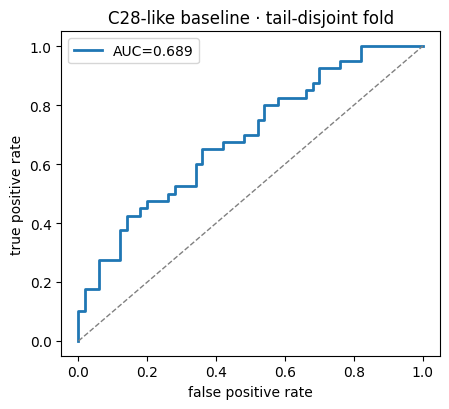

On real C28, expect this BELOW the paper's ~0.82 — bridge-1 discards the
temporally-distant structure Conv-MHSA exploits. That gap is the point: it is
what the Conv-MHSA swap (Step 5) is there to close.


In [7]:
# ROC on one tail-disjoint fold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_curve, roc_auc_score
X = table[feat_cols].values; y = table['label'].values.astype(int); g = table['group'].values
tr, te = next(GroupKFold(5).split(X, y, g))
clf = HistGradientBoostingClassifier(random_state=0).fit(X[tr], y[tr])
p = clf.predict_proba(X[te])[:, 1]
fpr, tpr, _ = roc_curve(y[te], p)
plt.figure(figsize=(4.6,4.2))
plt.plot(fpr, tpr, lw=2, label=f"AUC={roc_auc_score(y[te],p):.3f}")
plt.plot([0,1],[0,1],'--',color='gray',lw=1)
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("C28-like baseline · tail-disjoint fold"); plt.legend(); plt.tight_layout(); plt.show()
print("On real C28, expect this BELOW the paper's ~0.82 — bridge-1 discards the\n"
      "temporally-distant structure Conv-MHSA exploits. That gap is the point: it is\n"
      "what the Conv-MHSA swap (Step 5) is there to close.")

### Optional · honour the paper's own split
The file ships a `split` column (the paper's train/test partition). Reproducing it lets
you compare like-for-like with the paper, alongside your GroupKFold number.

In [8]:
tr_mask = table['paper_split'].eq('train').values
te_mask = table['paper_split'].eq('test').values
if tr_mask.any() and te_mask.any() and len(np.unique(y[te_mask])) == 2:
    c = HistGradientBoostingClassifier(random_state=0).fit(X[tr_mask], y[tr_mask])
    auc = roc_auc_score(y[te_mask], c.predict_proba(X[te_mask])[:,1])
    print(f"paper-split holdout AUC: {auc:.3f}  "
          f"(train tails={pd.Series(g[tr_mask]).nunique()}, test tails={pd.Series(g[te_mask]).nunique()})")
else:
    print("paper split not usable in this sample (single-class test fold)")

paper-split holdout AUC: 0.758  (train tails=19, test tails=5)


## 4 · Run the agent tools on REAL-format flights
The orchestrator must never touch the 4 GB file. `export_flights_to_dir` materialises a
small batch of real flights as per-flight CSVs + metadata, so the **existing**
inspect/featurize/classify/recommend tools — the exact ones OpenClaw drives in Step 2 —
run unchanged on real data.

In [9]:
fd, mp = export_flights_to_dir(BIG_CSV, WORK/"batch", max_flights=40)
insp = tools.inspect_data(str(fd), str(mp))
print("inspect on real-format flights:")
print(json.dumps({k: insp[k] for k in ['n_flights','label_balance','n_planes','n_channels','example_flight_steps']}, indent=2))
print("detected channels:", insp['detected_channels'][:6], "...", insp['detected_channels'][-3:])
tools.featurize_flights(str(fd), str(mp), str(WORK/"batch_feats.csv"))
r = tools.classify_flights(str(WORK/"batch_feats.csv"), str(WORK/"c28_model.joblib"), str(WORK/"batch_preds.json"))
print("classify on real-format flights:", {k: r[k] for k in ['n_scored','n_high']})

[realdata] exported 40 flights -> nb2_work/batch/flights (+ metadata.csv)
inspect on real-format flights:
{
  "n_flights": 40,
  "label_balance": {
    "0": 30,
    "1": 10
  },
  "n_planes": 3,
  "n_channels": 22,
  "example_flight_steps": 512
}
detected channels: ['volt2', 'amp1', 'amp2', 'FQtyL', 'FQtyR', 'E1 FFlow'] ... ['VSpd', 'NormAc', 'AltMSL']
classify on real-format flights: {'n_scored': 40, 'n_high': 10}


## 5 · The exact commands for the real 4 GB file

Everything above ran in-process on a mock; on the real download use the offline CLI
(`realdata` has its own entry point — this is the one-time prep, like training, not an
agent tool):

```bash
# 1. sanity-check the first chunk (seconds, not minutes)
python -m aviation_mas_mvp.realdata peek --csv C28.csv --nrows 200000

# 2. stream the whole 4 GB file -> tabular feature table (one-time, memory-safe)
python -m aviation_mas_mvp.realdata featurize --csv C28.csv --out c28_feats.csv --chunksize 500000

# 3. train the honest tail-disjoint baseline + save model
python -c "import pandas as pd; from aviation_mas_mvp.train_baseline import train; \
           train(pd.read_csv('c28_feats.csv'), 'c28_model.joblib', 'c28_metrics.json')"

# 4. export a small real-flight batch for the Step-2 OpenClaw demo
python -m aviation_mas_mvp.realdata export --csv C28.csv --out-dir c28_batch --max-flights 50
```

## What's validated / next
- **Validated:** the real big-CSV schema maps cleanly onto the Step-0 pipeline; the
  streaming featurizer is memory-safe and chunk-invariant; `before_after` is the label;
  tail-disjoint GroupKFold gives the honest baseline; real-format flights run through the
  unchanged agent tools.
- **Next — Step 2 (OpenClaw):** point the agent at the `c28_batch` directory and the
  `c28_model.joblib`, wire the four CLI tools (`openclaw/tools_manifest.md`), run
  `qwen3-coder:30b` non-headless, and diff the agent trace against `orchestrator_sim`.
- **Headline discipline:** report the C28 GroupKFold AUC as a **baseline**. The
  orchestration loop is the MVP deliverable; the Conv-MHSA swap (Step 5) carries accuracy.